# Laser Code

In [ ]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

In [ ]:
############################ TURN LASER ON ############################ 
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

# Set Instruments Code

In [ ]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

params.laser_set_standard(laser, wavelength=1550e-9, power=7)
params.laser_get_standard(laser)
params.pmeter_set_standard(pmeter=pm100d, wavelength=1550e-9)
params.pmeter_set_standard(pmeter=pms120, wavelength=1550e-9)
params.MSO5_set_standard_counts(MS)
p_att.write(f'VOLT {params.device_line_1['v_attenuator_vals']['att_blue_v']}')
# yoko.current(0)
# Check shielding: box and fridge entry 

# Import

In [2]:
import time
from time import sleep, monotonic
import datetime
import numpy as np
import matplotlib.pyplot as plt
import sys
import pyvisa
import qcodes as qc
from qcodes.dataset import Measurement
from qcodes.dataset import do0d
from qcodes.dataset.experiment_container import new_experiment, load_experiment_by_name
from qcodes.dataset.plotting import plot_by_id
from qcodes.dataset.data_set import load_by_id, load_by_counter
from qcodes import initialise_or_create_database_at, new_data_set, new_experiment
from qcodes.station import Station
initialise_or_create_database_at("./2026-05-11_SNSPD11.db")
import snspd
params = snspd.snspd('snspd11.yaml')

# Set up experiment
exp_name = 'SNSPD11_11_05_2026'
sample_name = '00'

try:
    exp = qc.load_experiment_by_name(exp_name, sample=sample_name)
    print('Experiment loaded. Last ID no:', exp.last_counter)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
    print('Started new experiment')

Logging hadn't been started.
Activating auto-logging. Current session state plus future input saved.
Filename       : C:\Users\QNL\.qcodes\logs\command_history.log
Mode           : append
Output logging : True
Raw input log  : False
Timestamping   : True
State          : active
Qcodes Logfile : C:\Users\QNL\.qcodes\logs\260522-36880-qcodes.log
Experiment loaded. Last ID no: 275


In [2]:
import importlib
importlib.reload(snspd)
params = snspd.snspd('snspd11.yaml')

In [2]:
import pyvisa
rm = pyvisa.ResourceManager()

In [4]:
rm.list_resources()

('TCPIP0::10.196.52.98::inst0::INSTR',
 'TCPIP0::10.196.52.96::inst0::INSTR',
 'ASRL1::INSTR',
 'ASRL2::INSTR',
 'ASRL5::INSTR',
 'ASRL6::INSTR',
 'ASRL7::INSTR',
 'ASRL8::INSTR',
 'ASRL9::INSTR',
 'ASRL10::INSTR',
 'ASRL11::INSTR',
 'ASRL12::INSTR',
 'ASRL13::INSTR',
 'TCPIP0::10.196.50.27::inst0::INSTR',
 'USB0::0x05E6::0x2230::9010428::0::INSTR',
 'USB0::0x1313::0x8072::1906768::0::INSTR',
 'USB0::0x1313::0x8072::1913782::0::INSTR',
 'USB0::0x1313::0x8078::P0033329::0::INSTR')

In [6]:
station = Station(config_file="friesland.yaml")
laser = station.load_instrument("laser", revive_instance=True)

NameError: name 'Station' is not defined

# Instruments

In [5]:
station = Station(config_file="friesland.yaml")
dmm = station.load_instrument("dmm", revive_instance=True)
yoko = station.load_instrument("yoko", revive_instance=True)
laser = station.load_instrument("laser", revive_instance=True)
MS = station.load_instrument("osc", revive_instance=True)
pm100d = station.load_instrument("pm100d", revive_instance=True) 
pms120 = station.load_instrument("pms120", revive_instance=True)
tc = station.load_instrument("fridge", revive_instance=True)
p_att = station.load_instrument("dmm_keithley", revive_instance=True) # excluding from snapshot because none of the parameters work anyway

In [6]:
params.initialize_station()

With isolation transformer connected 

# Light Counts vs Current 

Trying to run identical code block to ID 252

([<Axes: title={'center': 'Run #275, Experiment SNSPD11_11_05_2026 (00)'}, xlabel='Current ($10^{-6}$ I)', ylabel='cps'>,
  <Axes: title={'center': 'Run #275, Experiment SNSPD11_11_05_2026 (00)'}, xlabel='Current ($10^{-6}$ I)', ylabel='cps'>],
 [None, None])

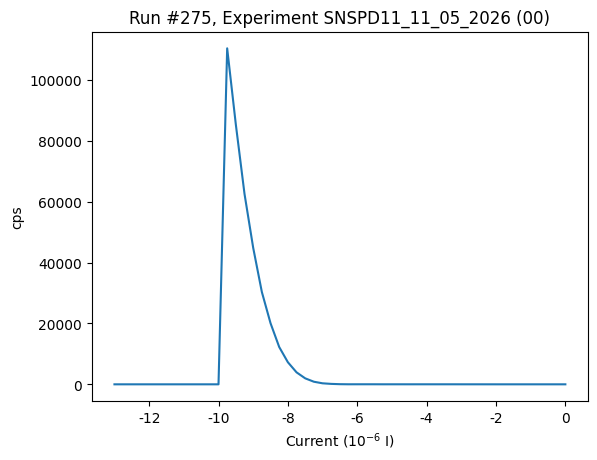

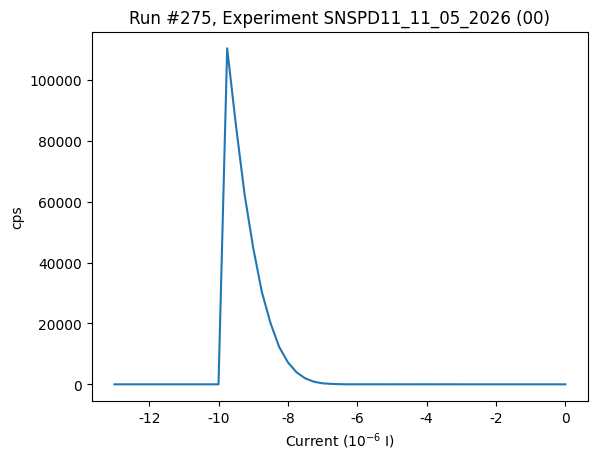

In [4]:
plot_by_id(275)

Check match:110472.0 (test) = [110472.]?


array([-9.75e-06])

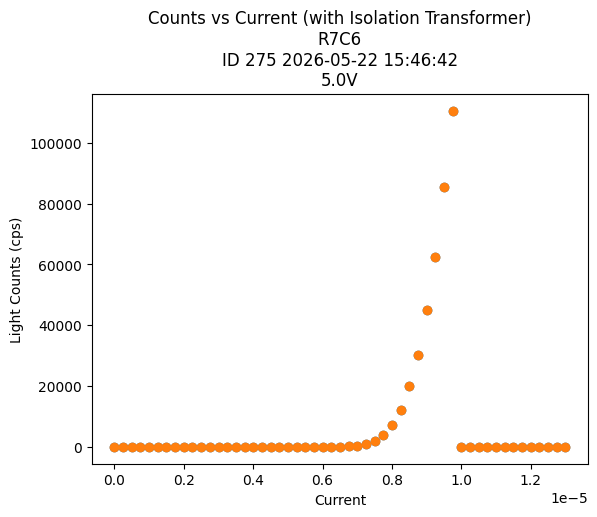

In [8]:
ID = 275
data = load_by_id(ID).get_parameter_data()
CR1 = data['CR1']['CR1']
CR2 = data['CR2']['CR2']
current = data['CR1']['yoko_current']
v_attenuator = data['v_attenuator']['v_attenuator']
plt.plot(-current, CR1, 'o', label='Threshold 1 (HIGH)')
plt.plot(-current, CR2, 'o', label='Threshold 2 (LOW)')
plt.title(params.make_title(ID=ID, title=f'Counts vs Current (with Isolation Transformer)\n{params.device_line_2['name']}', extra = f'{v_attenuator[0]}V'))
plt.xlabel('Current')
plt.ylabel('Light Counts (cps)')

idx, _ = params.match(max(CR1), CR1, tol=5)
current[idx]

In [10]:
data['threshold1']

{'threshold1': array([0.024, 0.024, 0.024, 0.024, 0.024, 0.024, 0.024, 0.024, 0.024,
        0.024, 0.024, 0.024, 0.024, 0.024, 0.024, 0.024, 0.052, 0.052,
        0.052, 0.052, 0.052, 0.052, 0.052, 0.052, 0.052, 0.052, 0.052,
        0.052, 0.052, 0.052, 0.052, 0.052, 0.06 , 0.06 , 0.06 , 0.06 ,
        0.06 , 0.06 , 0.06 , 0.06 , 0.06 , 0.06 , 0.06 , 0.06 , 0.06 ,
        0.06 , 0.06 , 0.06 , 0.06 , 0.06 , 0.06 , 0.06 , 0.06 ,   nan,
          nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,
          nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,
          nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,
          nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,
          nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,
          nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,
          nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,
          nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,

([<Axes: title={'center': 'Run #280, Experiment SNSPD11_11_05_2026 (00)'}, xlabel='time_axis', ylabel='trace'>],
 [None])

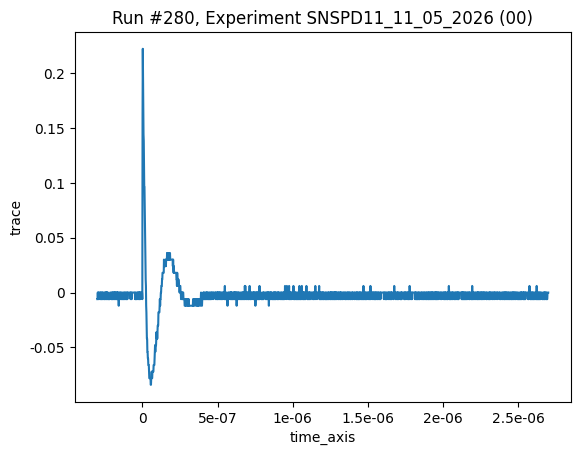

In [6]:
plot_by_id(280)

Similar amplitude. Different count rate. 